<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/power/ammonia_power_generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Power production from ammonia with NeqSim

This tutorial develops a screening model for direct-fired ammonia power generation in a simple
Brayton cycle. It is intended for process, energy, and mechanical engineers who know basic
thermodynamics and Python. Prerequisites are steady-flow energy balances, idealized gas-turbine
cycles, and introductory phase-equilibrium concepts. No local files or proprietary data are used.

In [1]:
import importlib.util
import subprocess
import sys


if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )

## Learning objectives and scope

After completing the notebook, you can:

1. derive ammonia lower heating value from standard formation enthalpies;
2. compress air with isentropic efficiency and NeqSim PS/PH flashes;
3. construct atom-balanced combustion products and solve fuel flow for a target turbine-inlet
   temperature;
4. expand the hot gas through a turbine and close the cycle power balance;
5. represent the states as NeqSim fluids, streams, compressor, and expander objects; and
6. evaluate pressure ratio, firing temperature, and generator-efficiency sensitivities.

The model is a thermodynamic screening calculation. It does not predict flame stability,
combustor pressure dynamics, NOx, N2O, ammonia slip, catalyst performance, or materials life.

In [2]:
import platform
import subprocess
from importlib import metadata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from neqsim import jneqsim
from neqsim.process import clearProcess, compressor, expander, runProcess, stream


neqsim_version = metadata.version("neqsim")
java_version_line = subprocess.run(
    ["java", "-version"],
    capture_output=True,
    check=True,
    text=True,
).stderr.splitlines()[0]

print(f"Python version: {platform.python_version()}")
print(f"NeqSim package version: {neqsim_version}")
print(f"Java runtime: {java_version_line}")

Python version: 3.12.13
NeqSim package version: 3.16.0
Java runtime: openjdk version "17.0.19" 2026-04-21


## Engineering model and units

The system boundary contains an air compressor, an idealized steady combustor, and a turbine.
Kinetic and potential energy changes and casing heat loss are neglected. Pressure is reported in
bara, temperature in K or °C, mass flow in kg/s, specific enthalpy in kJ/kg, and power in kW.

For a steady adiabatic compressor, the specific work is

$$
w_c = h_2-h_1 = \frac{h_{2s}-h_1}{\eta_c}.
$$

Here $h$ is specific enthalpy in kJ/kg, $\eta_c$ is compressor isentropic efficiency, and subscript
$s$ denotes an isentropic outlet. NeqSim solves the isentropic state with a PS flash and the actual
state with a PH flash.

In [3]:
THERMODYNAMIC_OPERATIONS = (
    jneqsim.thermodynamicoperations.ThermodynamicOperations
)
AMMONIA_MOLAR_MASS_KG_PER_KMOL = 17.03052
REFERENCE_TEMPERATURE_K = 298.15


def initialize_properties(fluid):
    operations = THERMODYNAMIC_OPERATIONS(fluid)
    operations.TPflash()
    fluid.initProperties()
    return fluid


def make_air(temperature_k, pressure_bara):
    air = jneqsim.thermo.system.SystemSrkEos(
        temperature_k,
        pressure_bara,
    )
    air.addComponent("nitrogen", 0.79)
    air.addComponent("oxygen", 0.21)
    air.setMixingRule("classic")
    air.init(0)
    return initialize_properties(air)

## Why SRK, and how NeqSim represents the calculation

The Soave–Redlich–Kwong equation of state is used because the working fluids are dilute or hot gas
mixtures, far from water condensation in the principal cycle states. It is a practical cubic model
for screening, not a substitute for calibrated combustion-property software. NeqSim stores
components, state variables, phases, and thermodynamic model in each fluid object. Flash operations
then solve a state under specified constraints.

At process level, a stream carries a cloned thermodynamic system and flow rate. Compressor and
expander unit operations transform inlet streams. The combustor outlet is constructed from explicit
atom and energy balances because this tutorial assumes complete conversion rather than solving
finite-rate reaction kinetics.

In [4]:
ambient_temperature_k = 288.15
ambient_pressure_bara = 1.01325
air_mass_flow_kg_s = 10.0
pressure_ratio = 12.0
compressor_efficiency = 0.82
turbine_efficiency = 0.88
combustor_pressure_loss_fraction = 0.04
turbine_inlet_temperature_k = 1473.15
generator_efficiency = 0.98

air_inlet = make_air(
    ambient_temperature_k,
    ambient_pressure_bara,
)

air_inlet_table = pd.DataFrame(
    {
        "Quantity": ["Temperature", "Pressure", "Mass flow"],
        "Value": [ambient_temperature_k, ambient_pressure_bara, air_mass_flow_kg_s],
        "Unit": ["K", "bara", "kg/s"],
    }
)
print(air_inlet_table.to_string(index=False))

   Quantity     Value Unit
Temperature 288.15000    K
   Pressure   1.01325 bara
  Mass flow  10.00000 kg/s


## Compression calculation

The compressor pressure ratio is $r_p=P_2/P_1$. A pressure ratio of 12 and an isentropic
efficiency of 0.82 are transparent screening assumptions, not equipment guarantees. The function
below clones every state, avoiding hidden mutation of the inlet. The PS flash enforces $s_{2s}=s_1$;
the PH flash enforces the calculated actual enthalpy.

In [5]:
def compress_air(inlet_fluid, outlet_pressure_bara, efficiency):
    isentropic_outlet = inlet_fluid.clone()
    isentropic_outlet.setPressure(outlet_pressure_bara, "bara")
    inlet_entropy_kj_kgk = inlet_fluid.getEntropy("kJ/kgK")
    THERMODYNAMIC_OPERATIONS(isentropic_outlet).PSflash(
        inlet_entropy_kj_kgk,
        "kJ/kgK",
    )
    isentropic_outlet.initProperties()

    inlet_enthalpy_kj_kg = inlet_fluid.getEnthalpy("kJ/kg")
    isentropic_enthalpy_kj_kg = isentropic_outlet.getEnthalpy("kJ/kg")
    actual_enthalpy_kj_kg = inlet_enthalpy_kj_kg + (
        isentropic_enthalpy_kj_kg - inlet_enthalpy_kj_kg
    ) / efficiency

    actual_outlet = isentropic_outlet.clone()
    THERMODYNAMIC_OPERATIONS(actual_outlet).PHflash(
        actual_enthalpy_kj_kg,
        "kJ/kg",
    )
    actual_outlet.initProperties()
    specific_work_kj_kg = actual_enthalpy_kj_kg - inlet_enthalpy_kj_kg
    return actual_outlet, specific_work_kj_kg


compressor_outlet_pressure_bara = ambient_pressure_bara * pressure_ratio
air_after_compressor, compressor_specific_work_kj_kg = compress_air(
    air_inlet,
    compressor_outlet_pressure_bara,
    compressor_efficiency,
)
compressor_power_kw = compressor_specific_work_kj_kg * air_mass_flow_kg_s

print(f"Compressor outlet temperature: {air_after_compressor.getTemperature('K'):.3f} K")
print(f"Compressor power: {compressor_power_kw:.3f} kW")

Compressor outlet temperature: 640.823 K
Compressor power: 3657.006 kW


## Complete ammonia combustion and lower heating value

For complete combustion with no fuel-bound nitrogen oxidation, the atom-balanced reaction is

$$
\mathrm{NH_3 + 0.75\,O_2 \rightarrow 0.5\,N_2 + 1.5\,H_2O(g)}.
$$

The lower heating value uses water vapour as product. With standard formation enthalpies
$\Delta H_f^\circ$ in kJ/mol,

$$
\mathrm{LHV}=-\frac{1.5\Delta H_f^\circ(H_2O,g)-\Delta H_f^\circ(NH_3,g)}{M_{NH_3}}.
$$

The values below are traceable public constants. Oxygen and nitrogen have zero standard formation
enthalpy in their reference states. This convention excludes condensation heat recovery.

In [6]:
formation_enthalpy_ammonia_gas_kj_mol = -45.94
formation_enthalpy_water_vapour_kj_mol = -241.826

reaction_enthalpy_kj_mol = (
    1.5 * formation_enthalpy_water_vapour_kj_mol
    - formation_enthalpy_ammonia_gas_kj_mol
)
ammonia_lhv_kj_kg = (
    -reaction_enthalpy_kj_mol
    / (AMMONIA_MOLAR_MASS_KG_PER_KMOL / 1000.0)
)

print(f"Derived ammonia LHV: {ammonia_lhv_kj_kg / 1000.0:.4f} MJ/kg")
assert 18.4 < ammonia_lhv_kj_kg / 1000.0 < 18.8

Derived ammonia LHV: 18.6018 MJ/kg


## Atom-balanced product fluid and combustor energy balance

Dry air is represented as 79 mol% nitrogen and 21 mol% oxygen. For each kmol of ammonia, the
model consumes 0.75 kmol of oxygen and forms 0.5 kmol of nitrogen plus 1.5 kmol of water. Excess
oxygen remains in the product. The excess-air ratio is $\lambda=n_{O_2,in}/n_{O_2,stoich}$.

Fuel flow is found by bisection so that the chemical heat release plus sensible enthalpy entering
with compressed air equals product sensible enthalpy at the specified turbine-inlet temperature.
Reference-state enthalpy differences are used consistently, so NeqSim's arbitrary absolute
enthalpy datum cancels.

In [7]:
def make_combustion_products(
    fuel_mass_flow_kg_s,
    air_mass_flow_kg_s,
    temperature_k,
    pressure_bara,
):
    reference_air = make_air(
        REFERENCE_TEMPERATURE_K,
        pressure_bara,
    )
    air_molar_mass_kg_kmol = reference_air.getMolarMass() * 1000.0
    air_flow_kmol_s = air_mass_flow_kg_s / air_molar_mass_kg_kmol
    fuel_flow_kmol_s = (
        fuel_mass_flow_kg_s / AMMONIA_MOLAR_MASS_KG_PER_KMOL
    )

    nitrogen_flow_kmol_s = 0.79 * air_flow_kmol_s + 0.5 * fuel_flow_kmol_s
    oxygen_flow_kmol_s = 0.21 * air_flow_kmol_s - 0.75 * fuel_flow_kmol_s
    water_flow_kmol_s = 1.5 * fuel_flow_kmol_s
    if oxygen_flow_kmol_s <= 0.0:
        raise ValueError("The assumed fuel flow exceeds available oxygen.")

    total_product_flow_kmol_s = (
        nitrogen_flow_kmol_s + oxygen_flow_kmol_s + water_flow_kmol_s
    )
    product = jneqsim.thermo.system.SystemSrkEos(
        temperature_k,
        pressure_bara,
    )
    product.addComponent(
        "nitrogen",
        nitrogen_flow_kmol_s / total_product_flow_kmol_s,
    )
    product.addComponent(
        "oxygen",
        oxygen_flow_kmol_s / total_product_flow_kmol_s,
    )
    product.addComponent(
        "water",
        water_flow_kmol_s / total_product_flow_kmol_s,
    )
    product.setMixingRule("classic")
    product = initialize_properties(product)

    flows = {
        "air_kmol_s": air_flow_kmol_s,
        "fuel_kmol_s": fuel_flow_kmol_s,
        "nitrogen_kmol_s": nitrogen_flow_kmol_s,
        "oxygen_kmol_s": oxygen_flow_kmol_s,
        "water_kmol_s": water_flow_kmol_s,
    }
    return product, flows

In [8]:
combustor_outlet_pressure_bara = compressor_outlet_pressure_bara * (
    1.0 - combustor_pressure_loss_fraction
)
reference_air_at_combustor_pressure = make_air(
    REFERENCE_TEMPERATURE_K,
    combustor_outlet_pressure_bara,
)
air_sensible_power_kw = air_mass_flow_kg_s * (
    air_after_compressor.getEnthalpy("kJ/kg")
    - reference_air_at_combustor_pressure.getEnthalpy("kJ/kg")
)


def combustor_energy_residual_kw(fuel_mass_flow_kg_s):
    hot_product, _ = make_combustion_products(
        fuel_mass_flow_kg_s,
        air_mass_flow_kg_s,
        turbine_inlet_temperature_k,
        combustor_outlet_pressure_bara,
    )
    reference_product, _ = make_combustion_products(
        fuel_mass_flow_kg_s,
        air_mass_flow_kg_s,
        REFERENCE_TEMPERATURE_K,
        combustor_outlet_pressure_bara,
    )
    product_sensible_power_kw = (
        air_mass_flow_kg_s + fuel_mass_flow_kg_s
    ) * (
        hot_product.getEnthalpy("kJ/kg")
        - reference_product.getEnthalpy("kJ/kg")
    )
    available_power_kw = (
        air_sensible_power_kw
        + fuel_mass_flow_kg_s * ammonia_lhv_kj_kg
    )
    return product_sensible_power_kw - available_power_kw


lower_fuel_bound_kg_s = 0.0
upper_fuel_bound_kg_s = 1.2
for _ in range(60):
    trial_fuel_flow_kg_s = 0.5 * (
        lower_fuel_bound_kg_s + upper_fuel_bound_kg_s
    )
    if combustor_energy_residual_kw(trial_fuel_flow_kg_s) > 0.0:
        lower_fuel_bound_kg_s = trial_fuel_flow_kg_s
    else:
        upper_fuel_bound_kg_s = trial_fuel_flow_kg_s

fuel_mass_flow_kg_s = 0.5 * (
    lower_fuel_bound_kg_s + upper_fuel_bound_kg_s
)
combustion_product, product_flows = make_combustion_products(
    fuel_mass_flow_kg_s,
    air_mass_flow_kg_s,
    turbine_inlet_temperature_k,
    combustor_outlet_pressure_bara,
)

print(f"Ammonia fuel flow: {fuel_mass_flow_kg_s:.6f} kg/s")
print(f"Combustor energy residual: {combustor_energy_residual_kw(fuel_mass_flow_kg_s):.3e} kW")

Ammonia fuel flow: 0.900063 kg/s
Combustor energy residual: -3.638e-12 kW


## Combustor verification: atoms, mass, phase, and excess air

An energy solver can converge while chemistry is wrong. Independent nitrogen, hydrogen, and oxygen
atom balances therefore accompany the heat balance. Complete conversion implies zero ammonia in
the idealized outlet. At this high temperature, the equilibrium phase should be gas. The model does
not include dissociation, so it becomes less reliable as firing temperature rises.

In [9]:
fuel_kmol_s = product_flows["fuel_kmol_s"]
air_kmol_s = product_flows["air_kmol_s"]
nitrogen_in_atoms_kmol_s = 2.0 * 0.79 * air_kmol_s + fuel_kmol_s
nitrogen_out_atoms_kmol_s = 2.0 * product_flows["nitrogen_kmol_s"]
hydrogen_in_atoms_kmol_s = 3.0 * fuel_kmol_s
hydrogen_out_atoms_kmol_s = 2.0 * product_flows["water_kmol_s"]
oxygen_in_atoms_kmol_s = 2.0 * 0.21 * air_kmol_s
oxygen_out_atoms_kmol_s = (
    2.0 * product_flows["oxygen_kmol_s"]
    + product_flows["water_kmol_s"]
)

atom_residuals = np.array(
    [
        nitrogen_out_atoms_kmol_s - nitrogen_in_atoms_kmol_s,
        hydrogen_out_atoms_kmol_s - hydrogen_in_atoms_kmol_s,
        oxygen_out_atoms_kmol_s - oxygen_in_atoms_kmol_s,
    ]
)
excess_air_ratio = (
    0.21 * air_kmol_s / (0.75 * fuel_kmol_s)
)
product_mass_flow_kg_s = air_mass_flow_kg_s + fuel_mass_flow_kg_s

print(f"Maximum atom residual: {np.max(np.abs(atom_residuals)):.3e} kmol atom/s")
print(f"Excess-air ratio, lambda: {excess_air_ratio:.4f}")
print(f"Product mass flow: {product_mass_flow_kg_s:.6f} kg/s")

assert np.max(np.abs(atom_residuals)) < 1.0e-12
assert excess_air_ratio > 1.0
assert combustion_product.getNumberOfPhases() == 1

Maximum atom residual: 0.000e+00 kmol atom/s
Excess-air ratio, lambda: 1.8364
Product mass flow: 10.900063 kg/s


## Product composition and engineering interpretation

The outlet contains nitrogen, unused oxygen, and water vapour. There is no carbon in the fuel or
air model, so direct stack CO2 is exactly zero by construction. That is not a claim of zero
lifecycle emissions: ammonia production, transport, and upstream electricity or natural gas can
dominate the lifecycle footprint. The high residual oxygen is a consequence of the chosen firing
temperature and simple dry-air dilution.

In [10]:
product_components = ["nitrogen", "oxygen", "water"]
product_composition = pd.DataFrame(
    {
        "Component": product_components,
        "Mole fraction [mol/mol]": [
            combustion_product.getComponent(component).getz()
            for component in product_components
        ],
    }
)
product_composition["Mole percent [%]"] = (
    100.0 * product_composition["Mole fraction [mol/mol]"]
)
print(product_composition.to_string(index=False))

Component  Mole fraction [mol/mol]  Mole percent [%]
 nitrogen                 0.727568         72.756776
   oxygen                 0.080333          8.033304
    water                 0.192099         19.209920


## Turbine expansion

The turbine is treated as adiabatic with isentropic efficiency $\eta_t$:

$$
w_t = h_3-h_4 = \eta_t(h_3-h_{4s}).
$$

The isentropic outlet satisfies $s_{4s}=s_3$ at ambient pressure. NeqSim first solves that state
with a PS flash, then solves the actual outlet by PH flash. Positive $w_t$ denotes shaft work
produced. The hot exhaust is not cooled in the simple cycle, so recoverable heat is outside the
base power balance.

In [11]:
def expand_product(inlet_fluid, outlet_pressure_bara, efficiency):
    isentropic_outlet = inlet_fluid.clone()
    isentropic_outlet.setPressure(outlet_pressure_bara, "bara")
    inlet_entropy_kj_kgk = inlet_fluid.getEntropy("kJ/kgK")
    THERMODYNAMIC_OPERATIONS(isentropic_outlet).PSflash(
        inlet_entropy_kj_kgk,
        "kJ/kgK",
    )
    isentropic_outlet.initProperties()

    inlet_enthalpy_kj_kg = inlet_fluid.getEnthalpy("kJ/kg")
    isentropic_enthalpy_kj_kg = isentropic_outlet.getEnthalpy("kJ/kg")
    actual_enthalpy_kj_kg = inlet_enthalpy_kj_kg - efficiency * (
        inlet_enthalpy_kj_kg - isentropic_enthalpy_kj_kg
    )

    actual_outlet = isentropic_outlet.clone()
    THERMODYNAMIC_OPERATIONS(actual_outlet).PHflash(
        actual_enthalpy_kj_kg,
        "kJ/kg",
    )
    actual_outlet.initProperties()
    specific_work_kj_kg = inlet_enthalpy_kj_kg - actual_enthalpy_kj_kg
    return actual_outlet, specific_work_kj_kg


turbine_exhaust, turbine_specific_work_kj_kg = expand_product(
    combustion_product,
    ambient_pressure_bara,
    turbine_efficiency,
)
turbine_power_kw = turbine_specific_work_kj_kg * product_mass_flow_kg_s

print(f"Turbine exhaust temperature: {turbine_exhaust.getTemperature('K'):.3f} K")
print(f"Turbine shaft power: {turbine_power_kw:.3f} kW")

Turbine exhaust temperature: 923.756 K
Turbine shaft power: 8412.226 kW


## Cycle power and efficiency

Gross turbine power must first drive the air compressor. A generator efficiency of 0.98 converts
remaining shaft power to electricity. The simple-cycle LHV efficiency is

$$
\eta_{el}=\frac{\eta_g(\dot W_t-\dot W_c)}{\dot m_f\,\mathrm{LHV}}.
$$

$\dot W_t$ and $\dot W_c$ are in kW, fuel flow $\dot m_f$ is in kg/s, and LHV is in kJ/kg.
Auxiliary loads, fuel compression, cooling systems, and ammonia production energy are excluded.

In [12]:
net_shaft_power_kw = turbine_power_kw - compressor_power_kw
net_electric_power_kw = generator_efficiency * net_shaft_power_kw
fuel_thermal_input_kw = fuel_mass_flow_kg_s * ammonia_lhv_kj_kg
electric_efficiency = net_electric_power_kw / fuel_thermal_input_kw

performance_table = pd.DataFrame(
    {
        "Quantity": [
            "Fuel thermal input",
            "Compressor power",
            "Turbine shaft power",
            "Net electric power",
            "LHV electric efficiency",
            "Exhaust temperature",
        ],
        "Value": [
            fuel_thermal_input_kw,
            compressor_power_kw,
            turbine_power_kw,
            net_electric_power_kw,
            100.0 * electric_efficiency,
            turbine_exhaust.getTemperature("K"),
        ],
        "Unit": ["kW", "kW", "kW", "kW", "%", "K"],
    }
)
print(performance_table.to_string(index=False))

               Quantity        Value Unit
     Fuel thermal input 16742.830347   kW
       Compressor power  3657.005885   kW
    Turbine shaft power  8412.225716   kW
     Net electric power  4660.115435   kW
LHV electric efficiency    27.833499    %
    Exhaust temperature   923.755659    K


## Streams and unit operations in the NeqSim process layer

The direct flashes above expose every equation. The process layer now represents the same
compressor and turbine as connected unit operations. A separate ammonia stream records fuel flow.
The atom-balanced product stream is the combustor outlet; it is intentionally not a kinetic reactor.
This division makes the solver workflow explicit: calculate chemistry and heat release, construct
the product fluid, then pass that state to the turbine.

In [13]:
clearProcess()

process_air_fluid = air_inlet.clone()
process_air_fluid.setTotalFlowRate(air_mass_flow_kg_s, "kg/sec")
air_feed_stream = stream("Air feed", process_air_fluid)
air_compressor = compressor(
    "Air compressor",
    air_feed_stream,
    compressor_outlet_pressure_bara,
)
air_compressor.setIsentropicEfficiency(compressor_efficiency)

fuel_fluid = jneqsim.thermo.system.SystemSrkEos(
    REFERENCE_TEMPERATURE_K,
    combustor_outlet_pressure_bara,
)
fuel_fluid.addComponent("ammonia", 1.0)
fuel_fluid.setMixingRule("classic")
fuel_fluid = initialize_properties(fuel_fluid)
fuel_fluid.setTotalFlowRate(fuel_mass_flow_kg_s, "kg/sec")
ammonia_fuel_stream = stream("Ammonia fuel", fuel_fluid)

process_product_fluid = combustion_product.clone()
process_product_fluid.setTotalFlowRate(product_mass_flow_kg_s, "kg/sec")
combustor_outlet_stream = stream(
    "Atom-balanced combustor outlet",
    process_product_fluid,
)
gas_turbine = expander(
    "Gas turbine",
    combustor_outlet_stream,
    ambient_pressure_bara,
)
gas_turbine.setIsentropicEfficiency(turbine_efficiency)

runProcess()

## Process-layer cross-check

Independent implementations should agree when they use the same model, inlet state, pressure,
flow, and efficiency. This cross-check catches unit mistakes and sign conventions. NeqSim reports
compressor power as consumption; expander power sign can depend on API convention, so its magnitude
is compared with the explicitly positive turbine output.

In [14]:
process_compressor_power_kw = air_compressor.getPower("kW")
process_turbine_power_kw = abs(gas_turbine.getPower("kW"))
compressor_relative_difference = (
    process_compressor_power_kw - compressor_power_kw
) / compressor_power_kw
turbine_relative_difference = (
    process_turbine_power_kw - turbine_power_kw
) / turbine_power_kw

process_check_table = pd.DataFrame(
    {
        "Unit": ["Compressor", "Turbine"],
        "Direct calculation [kW]": [compressor_power_kw, turbine_power_kw],
        "Process unit [kW]": [
            process_compressor_power_kw,
            process_turbine_power_kw,
        ],
        "Relative difference [-]": [
            compressor_relative_difference,
            turbine_relative_difference,
        ],
    }
)
print(process_check_table.to_string(index=False))

      Unit  Direct calculation [kW]  Process unit [kW]  Relative difference [-]
Compressor              3657.005885        3657.005884            -6.093070e-11
   Turbine              8412.225716        8412.225718             1.672243e-10


## Reusable cycle function and scenario assumptions

Sensitivity calculations rebuild every thermodynamic state, preventing hidden dependence on a
previous case. Each scenario holds ambient conditions, component efficiencies, pressure loss, and
air flow fixed. Fuel flow is solved anew to reach the chosen firing temperature. Results are valid
only within the complete-combustion, oxygen-rich region where the product remains a single gas phase.

In [15]:
def evaluate_cycle(case_pressure_ratio, case_turbine_inlet_temperature_k):
    case_compressor_pressure_bara = ambient_pressure_bara * case_pressure_ratio
    case_air_outlet, case_compressor_work_kj_kg = compress_air(
        air_inlet,
        case_compressor_pressure_bara,
        compressor_efficiency,
    )
    case_combustor_pressure_bara = case_compressor_pressure_bara * (
        1.0 - combustor_pressure_loss_fraction
    )
    case_reference_air = make_air(
        REFERENCE_TEMPERATURE_K,
        case_combustor_pressure_bara,
    )
    case_air_sensible_power_kw = air_mass_flow_kg_s * (
        case_air_outlet.getEnthalpy("kJ/kg")
        - case_reference_air.getEnthalpy("kJ/kg")
    )

    def case_residual_kw(case_fuel_flow_kg_s):
        hot_product, _ = make_combustion_products(
            case_fuel_flow_kg_s,
            air_mass_flow_kg_s,
            case_turbine_inlet_temperature_k,
            case_combustor_pressure_bara,
        )
        cold_product, _ = make_combustion_products(
            case_fuel_flow_kg_s,
            air_mass_flow_kg_s,
            REFERENCE_TEMPERATURE_K,
            case_combustor_pressure_bara,
        )
        required_power_kw = (
            air_mass_flow_kg_s + case_fuel_flow_kg_s
        ) * (
            hot_product.getEnthalpy("kJ/kg")
            - cold_product.getEnthalpy("kJ/kg")
        )
        available_power_kw = (
            case_air_sensible_power_kw
            + case_fuel_flow_kg_s * ammonia_lhv_kj_kg
        )
        return required_power_kw - available_power_kw

    lower_bound_kg_s = 0.0
    upper_bound_kg_s = 1.2
    for _ in range(50):
        trial_flow_kg_s = 0.5 * (lower_bound_kg_s + upper_bound_kg_s)
        if case_residual_kw(trial_flow_kg_s) > 0.0:
            lower_bound_kg_s = trial_flow_kg_s
        else:
            upper_bound_kg_s = trial_flow_kg_s

    case_fuel_flow_kg_s = 0.5 * (lower_bound_kg_s + upper_bound_kg_s)
    case_product, case_flows = make_combustion_products(
        case_fuel_flow_kg_s,
        air_mass_flow_kg_s,
        case_turbine_inlet_temperature_k,
        case_combustor_pressure_bara,
    )
    case_exhaust, case_turbine_work_kj_kg = expand_product(
        case_product,
        ambient_pressure_bara,
        turbine_efficiency,
    )
    case_compressor_power_kw = (
        case_compressor_work_kj_kg * air_mass_flow_kg_s
    )
    case_turbine_power_kw = case_turbine_work_kj_kg * (
        air_mass_flow_kg_s + case_fuel_flow_kg_s
    )
    case_net_power_kw = generator_efficiency * (
        case_turbine_power_kw - case_compressor_power_kw
    )
    case_efficiency = case_net_power_kw / (
        case_fuel_flow_kg_s * ammonia_lhv_kj_kg
    )
    case_lambda = (
        0.21 * case_flows["air_kmol_s"]
        / (0.75 * case_flows["fuel_kmol_s"])
    )
    return {
        "fuel_kg_s": case_fuel_flow_kg_s,
        "net_power_kw": case_net_power_kw,
        "efficiency": case_efficiency,
        "exhaust_temperature_k": case_exhaust.getTemperature("K"),
        "lambda": case_lambda,
    }

## Pressure-ratio sensitivity

Raising pressure ratio initially improves expansion work but also raises compressor work. With
fixed component efficiencies and firing temperature, net power should exhibit a finite optimum,
while simple-cycle efficiency can continue increasing across the tested range. A design decision
must also consider surge margin, blade cooling, combustor stability, cost, and part-load behaviour.

Maximum net power on tested grid occurs at pressure ratio 14.
Highest efficiency on the tested grid occurs at pressure ratio 30.


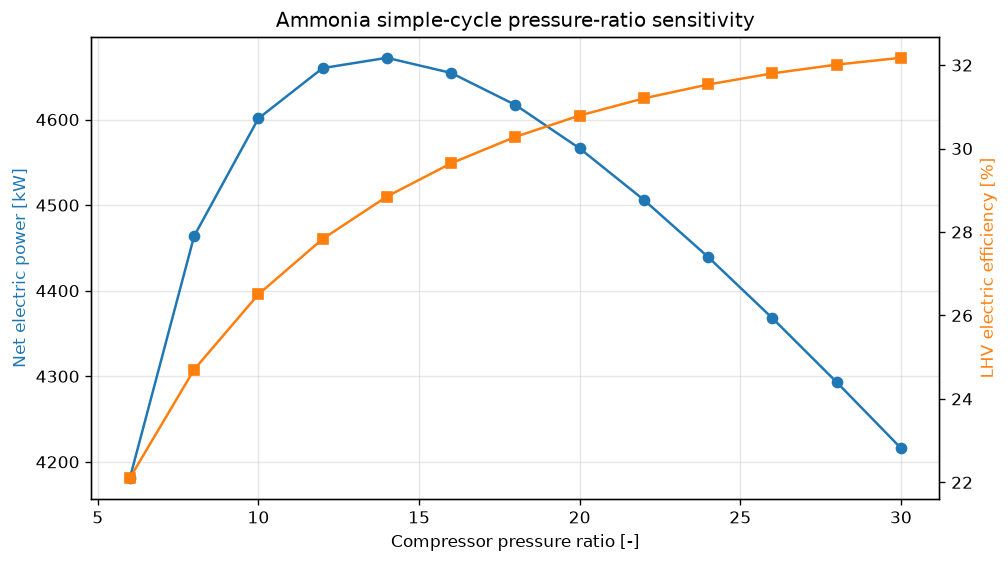

In [16]:
pressure_ratios = np.arange(6.0, 31.0, 2.0)
pressure_ratio_cases = [
    evaluate_cycle(case_ratio, turbine_inlet_temperature_k)
    for case_ratio in pressure_ratios
]
pressure_ratio_results = pd.DataFrame(pressure_ratio_cases)
pressure_ratio_results.insert(0, "pressure_ratio", pressure_ratios)

best_power_case_index = pressure_ratio_results["net_power_kw"].idxmax()
best_power_pressure_ratio = pressure_ratio_results.loc[
    best_power_case_index,
    "pressure_ratio",
]
highest_efficiency_pressure_ratio = pressure_ratio_results.loc[
    pressure_ratio_results["efficiency"].idxmax(),
    "pressure_ratio",
]

fig, left_axis = plt.subplots(figsize=(8.5, 4.8))
right_axis = left_axis.twinx()
left_axis.plot(
    pressure_ratios,
    pressure_ratio_results["net_power_kw"],
    marker="o",
    color="tab:blue",
    label="Net electric power",
)
right_axis.plot(
    pressure_ratios,
    100.0 * pressure_ratio_results["efficiency"],
    marker="s",
    color="tab:orange",
    label="LHV efficiency",
)
left_axis.set_xlabel("Compressor pressure ratio [-]")
left_axis.set_ylabel("Net electric power [kW]", color="tab:blue")
right_axis.set_ylabel("LHV electric efficiency [%]", color="tab:orange")
left_axis.grid(alpha=0.3)
plt.title("Ammonia simple-cycle pressure-ratio sensitivity")
plt.tight_layout()
plt.show()

print(f"Maximum net power on tested grid occurs at pressure ratio {best_power_pressure_ratio:.0f}.")
print(
    "Highest efficiency on the tested grid occurs at pressure ratio "
    f"{highest_efficiency_pressure_ratio:.0f}."
)

## Turbine-inlet-temperature sensitivity

Higher firing temperature generally increases specific turbine work and requires more fuel at
fixed air flow. The scenario range of 900–1300 °C is illustrative. Real upper limits depend on
materials, blade cooling, ammonia flame stabilization, and emissions controls. Complete products
without dissociation become less defensible at the high end.

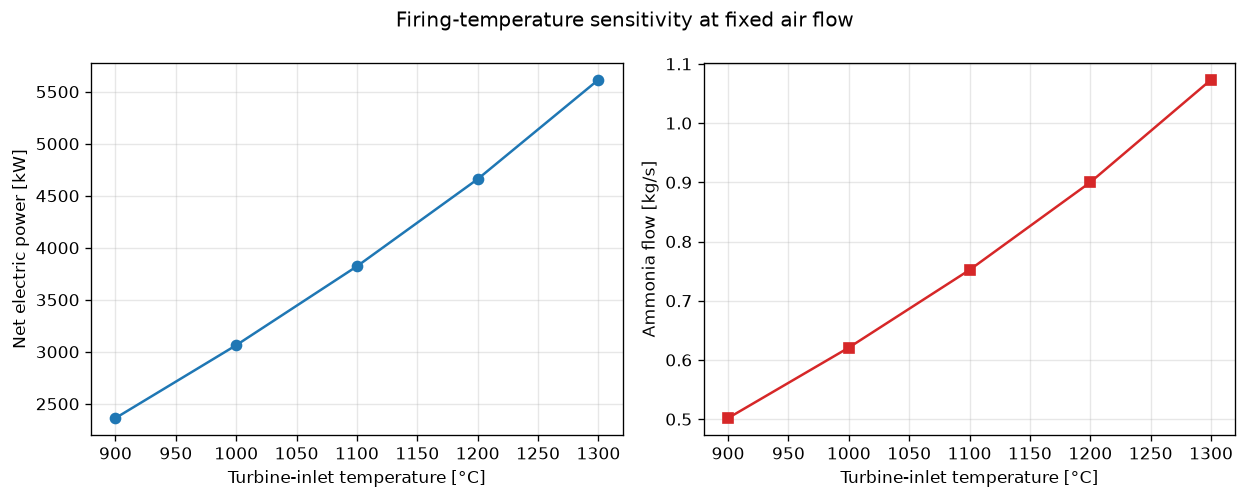

In [17]:
firing_temperatures_c = np.arange(900.0, 1301.0, 100.0)
firing_temperature_cases = [
    evaluate_cycle(pressure_ratio, temperature_c + 273.15)
    for temperature_c in firing_temperatures_c
]
firing_temperature_results = pd.DataFrame(firing_temperature_cases)
firing_temperature_results.insert(
    0,
    "temperature_c",
    firing_temperatures_c,
)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
axes[0].plot(
    firing_temperatures_c,
    firing_temperature_results["net_power_kw"],
    marker="o",
)
axes[0].set_xlabel("Turbine-inlet temperature [°C]")
axes[0].set_ylabel("Net electric power [kW]")
axes[0].grid(alpha=0.3)
axes[1].plot(
    firing_temperatures_c,
    firing_temperature_results["fuel_kg_s"],
    marker="s",
    color="tab:red",
)
axes[1].set_xlabel("Turbine-inlet temperature [°C]")
axes[1].set_ylabel("Ammonia flow [kg/s]")
axes[1].grid(alpha=0.3)
fig.suptitle("Firing-temperature sensitivity at fixed air flow")
plt.tight_layout()
plt.show()

## Generator and mechanical-loss sensitivity

Generator efficiency does not change the thermodynamic states, but it directly scales net
electric output after compressor work is deducted. The 0.94–0.99 range below illustrates why the
boundary between shaft power and exported electricity must be stated explicitly.

In [18]:
generator_efficiencies = np.array([0.94, 0.96, 0.98, 0.99])
generator_power_kw = generator_efficiencies * net_shaft_power_kw
generator_results = pd.DataFrame(
    {
        "Generator efficiency [-]": generator_efficiencies,
        "Net electric power [kW]": generator_power_kw,
        "LHV electric efficiency [%]": (
            100.0 * generator_power_kw / fuel_thermal_input_kw
        ),
    }
)
print(generator_results.to_string(index=False))

 Generator efficiency [-]  Net electric power [kW]  LHV electric efficiency [%]
                     0.94              4469.906642                    26.697437
                     0.96              4565.011038                    27.265468
                     0.98              4660.115435                    27.833499
                     0.99              4707.667633                    28.117514


## Limiting cases and thermodynamic bounds

A valid model should behave sensibly away from its design point. At zero fuel, the product helper
reduces to dry air and preserves its composition. Turbine work must be positive for expansion, net
power must be smaller than gross turbine power, and LHV efficiency must lie between zero and one.
The Carnot expression is not a gas-turbine efficiency prediction, but $1-T_0/T_3$ supplies a useful
upper-bound sanity check for any heat engine exchanging heat between those temperatures.

In [19]:
zero_fuel_product, zero_fuel_flows = make_combustion_products(
    0.0,
    air_mass_flow_kg_s,
    ambient_temperature_k,
    ambient_pressure_bara,
)
zero_fuel_nitrogen = zero_fuel_product.getComponent("nitrogen").getz()
zero_fuel_oxygen = zero_fuel_product.getComponent("oxygen").getz()
carnot_bound = 1.0 - ambient_temperature_k / turbine_inlet_temperature_k

print(f"Zero-fuel nitrogen mole fraction: {zero_fuel_nitrogen:.6f} mol/mol")
print(f"Zero-fuel oxygen mole fraction: {zero_fuel_oxygen:.6f} mol/mol")
print(f"Carnot reference bound: {100.0 * carnot_bound:.3f} %")

assert abs(zero_fuel_nitrogen - 0.79) < 1.0e-12
assert abs(zero_fuel_oxygen - 0.21) < 1.0e-12
assert 0.0 < electric_efficiency < carnot_bound < 1.0
assert 0.0 < net_electric_power_kw < turbine_power_kw

Zero-fuel nitrogen mole fraction: 0.790000 mol/mol
Zero-fuel oxygen mole fraction: 0.210000 mol/mol
Carnot reference bound: 80.440 %


## Exhaust heat-recovery potential

The simple-cycle exhaust remains hot. A lower-bound heat-recovery screen cools the same gas to
423.15 K (150 °C) at ambient pressure without condensation or pressure loss. The recoverable duty
is a sensible-heat estimate, not a steam-generator design. Water condensation, pinch constraints,
acid formation, pressure drop, and materials must be evaluated separately.

In [20]:
heat_recovery_outlet = turbine_exhaust.clone()
heat_recovery_outlet.setTemperature(423.15, "K")
heat_recovery_outlet.setPressure(ambient_pressure_bara, "bara")
heat_recovery_outlet = initialize_properties(heat_recovery_outlet)

recoverable_heat_kw = product_mass_flow_kg_s * (
    turbine_exhaust.getEnthalpy("kJ/kg")
    - heat_recovery_outlet.getEnthalpy("kJ/kg")
)
heat_to_power_ratio = recoverable_heat_kw / net_electric_power_kw

print(f"Sensible heat recoverable to 423.15 K: {recoverable_heat_kw:.3f} kW")
print(f"Recoverable-heat/net-power ratio: {heat_to_power_ratio:.4f}")

assert recoverable_heat_kw > 0.0
assert heat_recovery_outlet.getNumberOfPhases() == 1

Sensible heat recoverable to 423.15 K: 6637.430 kW
Recoverable-heat/net-power ratio: 1.4243


## Consolidated verification

The final checks cover finite values, balances, process/direct agreement, phase behaviour, and
expected scenario trends. Tight numerical tolerances are used only for identities solved by the
same thermodynamic model. Engineering assumptions such as complete combustion and efficiencies
remain model inputs rather than validated plant data.

In [21]:
engineering_checks = {
    "finite fuel flow": np.isfinite(fuel_mass_flow_kg_s),
    "finite net power": np.isfinite(net_electric_power_kw),
    "combustor energy closure": abs(
        combustor_energy_residual_kw(fuel_mass_flow_kg_s)
    ) < 1.0e-8,
    "atom closure": np.max(np.abs(atom_residuals)) < 1.0e-12,
    "oxygen-rich combustion": excess_air_ratio > 1.0,
    "positive compressor work": compressor_power_kw > 0.0,
    "positive turbine work": turbine_power_kw > 0.0,
    "positive net electric power": net_electric_power_kw > 0.0,
    "plausible efficiency": 0.15 < electric_efficiency < 0.60,
    "efficiency below Carnot reference": electric_efficiency < carnot_bound,
    "hot-gas phase": combustion_product.getNumberOfPhases() == 1,
    "exhaust gas phase": turbine_exhaust.getNumberOfPhases() == 1,
    "process compressor agreement": abs(compressor_relative_difference) < 1.0e-7,
    "process turbine agreement": abs(turbine_relative_difference) < 1.0e-7,
    "pressure study finite": np.isfinite(
        pressure_ratio_results["net_power_kw"]
    ).all(),
    "pressure study has interior power maximum": (
        0 < best_power_case_index < len(pressure_ratio_results) - 1
    ),
    "firing study finite": np.isfinite(
        firing_temperature_results["fuel_kg_s"]
    ).all(),
    "fuel rises with firing temperature": firing_temperature_results[
        "fuel_kg_s"
    ].is_monotonic_increasing,
    "power rises with firing temperature": firing_temperature_results[
        "net_power_kw"
    ].is_monotonic_increasing,
    "generator output rises with efficiency": np.all(
        np.diff(generator_power_kw) > 0.0
    ),
    "positive heat-recovery screen": recoverable_heat_kw > 0.0,
}

failed_checks = [
    name
    for name, passed in engineering_checks.items()
    if not passed
]
assert not failed_checks, f"Failed engineering checks: {failed_checks}"

print(f"Engineering checks passed: {len(engineering_checks)}")
print(f"Combustor energy residual: {combustor_energy_residual_kw(fuel_mass_flow_kg_s):.3e} kW")
print(f"Maximum atom residual: {np.max(np.abs(atom_residuals)):.3e} kmol atom/s")

Engineering checks passed: 21
Combustor energy residual: -3.638e-12 kW
Maximum atom residual: 0.000e+00 kmol atom/s


## State map

The temperature–entropy map provides a compact visual check of the compressor and turbine paths.
Entropy is specific entropy in kJ/(kg·K). Because combustion changes composition and mass flow, the
line between compressor outlet and turbine inlet is a process connection, not a reversible path for
one closed parcel of fluid.

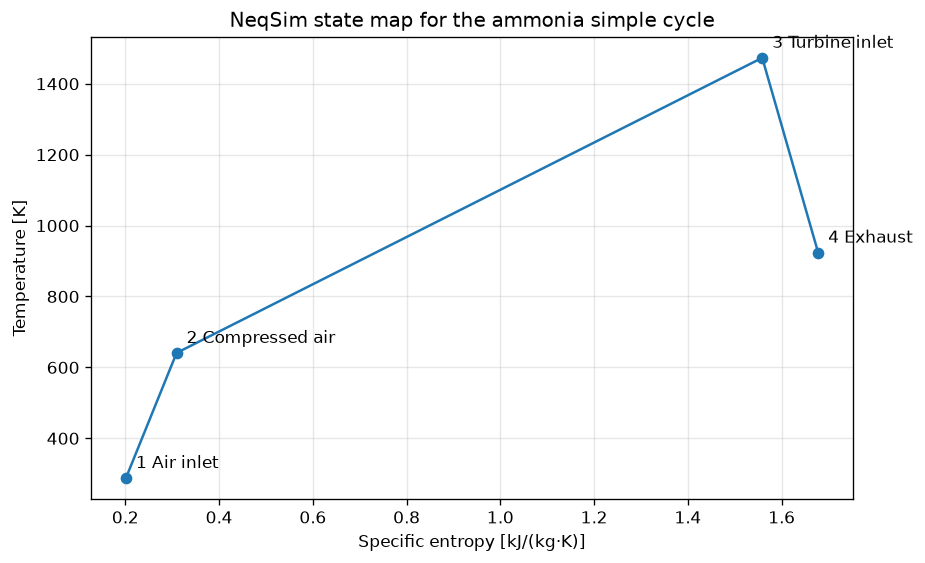

In [22]:
state_names = ["1 Air inlet", "2 Compressed air", "3 Turbine inlet", "4 Exhaust"]
state_temperatures_k = [
    air_inlet.getTemperature("K"),
    air_after_compressor.getTemperature("K"),
    combustion_product.getTemperature("K"),
    turbine_exhaust.getTemperature("K"),
]
state_entropies_kj_kgk = [
    air_inlet.getEntropy("kJ/kgK"),
    air_after_compressor.getEntropy("kJ/kgK"),
    combustion_product.getEntropy("kJ/kgK"),
    turbine_exhaust.getEntropy("kJ/kgK"),
]

plt.figure(figsize=(7.8, 4.8))
plt.plot(
    state_entropies_kj_kgk,
    state_temperatures_k,
    marker="o",
)
for state_name, entropy, temperature in zip(
    state_names,
    state_entropies_kj_kgk,
    state_temperatures_k,
):
    plt.annotate(
        state_name,
        (entropy, temperature),
        xytext=(6, 6),
        textcoords="offset points",
    )
plt.xlabel("Specific entropy [kJ/(kg·K)]")
plt.ylabel("Temperature [K]")
plt.title("NeqSim state map for the ammonia simple cycle")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Troubleshooting, limitations, and next steps

- If the fuel-flow bounds do not bracket a root, reduce firing temperature or increase air flow;
  never accept a negative product oxygen flow.
- If a PS or PH flash fails, verify units, initialize the inlet, and avoid reusing a mutated fluid.
- If liquid appears in a hot state, check temperature units and composition before changing solver
  settings.
- SRK, fixed efficiencies, dry air, complete combustion, and zero dissociation are screening
  assumptions. Real designs require validated property methods, pressure losses, cooling flows,
  ammonia vaporization, ignition and flame-stability models, NOx/N2O/NH3-slip chemistry, SCR or
  other treatment, dynamic control, safety studies, and materials assessment.

**Summary.** NeqSim supplies consistent thermodynamic states and process equipment calculations;
explicit stoichiometry and energy balance supply the idealized combustor. Together they quantify
fuel demand, compressor and turbine work, net electricity, sensitivity, and recoverable heat.

**Further exercises.** Add fuel preheating, humid air, intercooling, a recuperator, or a combined
cycle. Compare SRK with PR for hot-gas properties. Replace complete combustion with a validated
reaction model and report nitrogen-species emissions with appropriate experimental evidence.

**Authoritative references**

- [NeqSim thermodynamic models](https://equinor.github.io/neqsim/thermo/thermodynamic_models.html)
- [NeqSim process recipes](https://equinor.github.io/neqsim/cookbook/process-recipes.html)
- [NeqSim thermodynamic operations](https://equinor.github.io/neqsim/thermodynamicoperations/README.html)
- [NIST Chemistry WebBook: ammonia](https://webbook.nist.gov/cgi/cbook.cgi?ID=C7664417&Mask=1)
- [NIST Chemistry WebBook: water](https://webbook.nist.gov/cgi/cbook.cgi?ID=C7732185&Mask=1)
- ISO 3977-2, *Gas turbines — Procurement — Part 2: Standard reference conditions and ratings*